<a href="https://colab.research.google.com/github/onuralpArsln/MlAiTutorialProjects/blob/main/15-Segmentation/FastSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# FastSAM (Fast Segment Anything Model) Kullanım Rehberi

Bu eğitimde, FastSAM kullanarak bir görüntü üzerinde nesne segmentasyonu yapmayı öğreneceğiz. FastSAM, orijinal SAM modeline göre çok daha hızlı çalışacak şekilde optimize edilmiştir.

### 1. Adım: Gerekli Kütüphanelerin Kurulumu

Öncelikle FastSAM'i çalıştırmak için gerekli olan bağımlılıkları ve `ultralytics` paketini kurmamız gerekiyor.


In [1]:
!pip install -q ultralytics


### 2. Adım: Kütüphanelerin İçe Aktarılması ve Modelin Yüklenmesi

FastSAM modelini kullanmak için `FastSAM` sınıfını içe aktarıyoruz.


In [2]:
from ultralytics import FastSAM
from ultralytics.models.sam import Predictor
import matplotlib.pyplot as plt
import cv2
from google.colab import files
import os

# Model ağırlıklarını indiriyoruz (FastSAM-s en hızlı versiyondur)
model = FastSAM('FastSAM-s.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



### 3. Adım: Bir Resim Yükleme

Kendi bilgisayarınızdan bir resim seçmek için aşağıdaki hücreyi çalıştırın.


In [3]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"{img_path} yüklendi.")

Saving gettyimages-586890581.png to gettyimages-586890581.png
gettyimages-586890581.png yüklendi.



### 4. Adım: FastSAM ile Segmentasyon

Şimdi yüklediğiniz resim üzerinde modeli çalıştıralım.


In [4]:
# Sadece segmentasyon verisini hesaplıyoruz, mavi görselleştirmeyi atlıyoruz
results = model(
    img_path,
    device='cpu',
    retina_masks=True,
    imgsz=1024,
    conf=0.25,
    iou=0.7
)

print("Segmentasyon verileri başarıyla hesaplandı. Renkli görselleştirme bir sonraki hücrede gösteriliyor.")


image 1/1 /content/gettyimages-586890581.png: 1024x1024 40 objects, 2802.7ms
Speed: 26.6ms preprocess, 2802.7ms inference, 1008.2ms postprocess per image at shape (1, 3, 1024, 1024)
Segmentasyon verileri başarıyla hesaplandı. Renkli görselleştirme bir sonraki hücrede gösteriliyor.


### 4.1. Tüm Segmentlerin Renkli Gösterimi

Yukarıdaki görselde mavi tonlarının karışmasının sebebi segmentlerin üst üste binmesidir. Aşağıdaki kod, her bir segmenti farklı bir renkle boyayarak modelin neleri 'ayrı nesneler' olarak algıladığını gösterir.

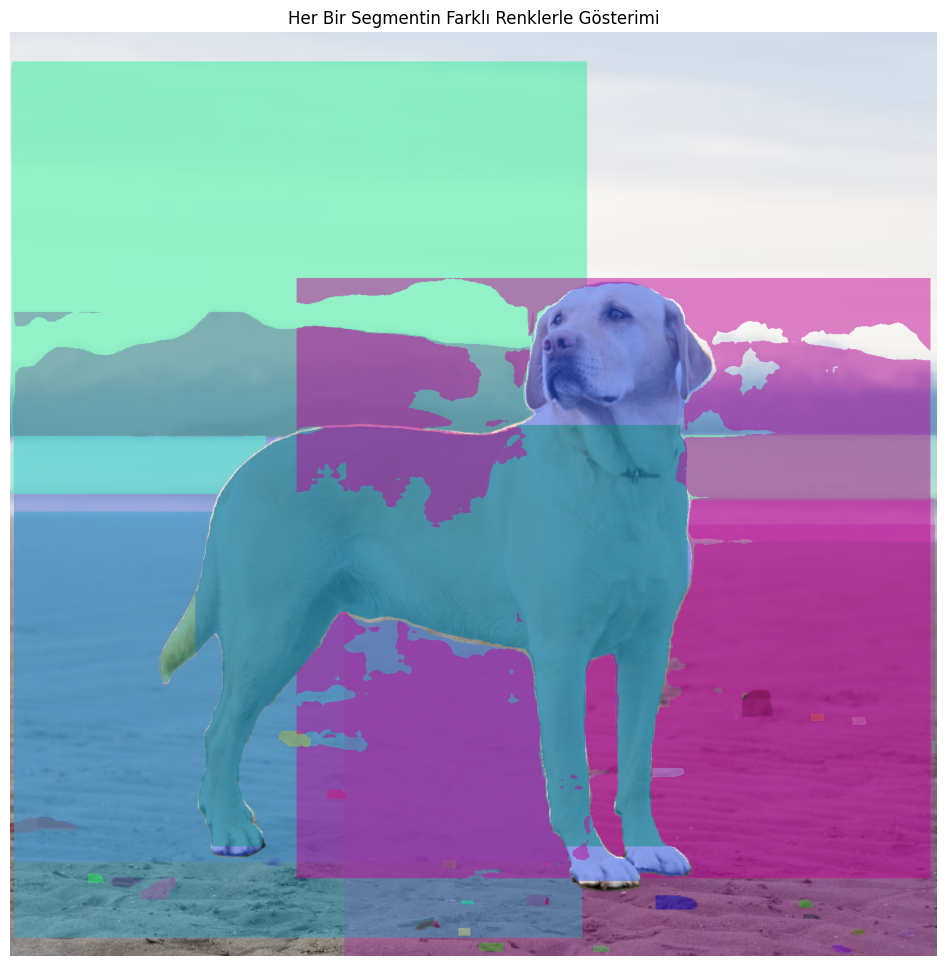

In [5]:
import numpy as np
import random

def get_colored_mask_image(results_obj, original_img):
    # Orijinal resmi kopyala
    annotated_img = original_img.copy()

    if results_obj[0].masks is not None:
        masks = results_obj[0].masks.data.cpu().numpy()

        for i in range(len(masks)):
            # Her segment için rastgele bir renk oluştur
            color = [random.randint(0, 255) for _ in range(3)]

            mask = masks[i]
            # Maske boyutunu resim boyutuna uyarla
            mask_resized = cv2.resize(mask, (annotated_img.shape[1], annotated_img.shape[0]))

            # Maskenin olduğu yerleri bu renge boya (yarı saydam)
            for c in range(3):
                annotated_img[:, :, c] = np.where(mask_resized > 0.5,
                                                annotated_img[:, :, c] * 0.5 + 0.5 * color[c],
                                                annotated_img[:, :, c])

    return annotated_img.astype(np.uint8)

# Orijinal resmi tekrar yükle
img_orig = cv2.imread(img_path)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

# Renkli segmentasyon sonucunu oluştur
colored_results = get_colored_mask_image(results, img_orig)

plt.figure(figsize=(12, 12))
plt.imshow(colored_results)
plt.axis('off')
plt.title("Her Bir Segmentin Farklı Renklerle Gösterimi")
plt.show()

### 4.2. Tespit Edilen Nesnelerin Kırpılmış (Crop) Gösterimi

Aşağıdaki kod, modelin tespit ettiği her bir nesnenin koordinatlarını alır ve orijinal resimden o bölgeyi kırparak yan yana gösterir.

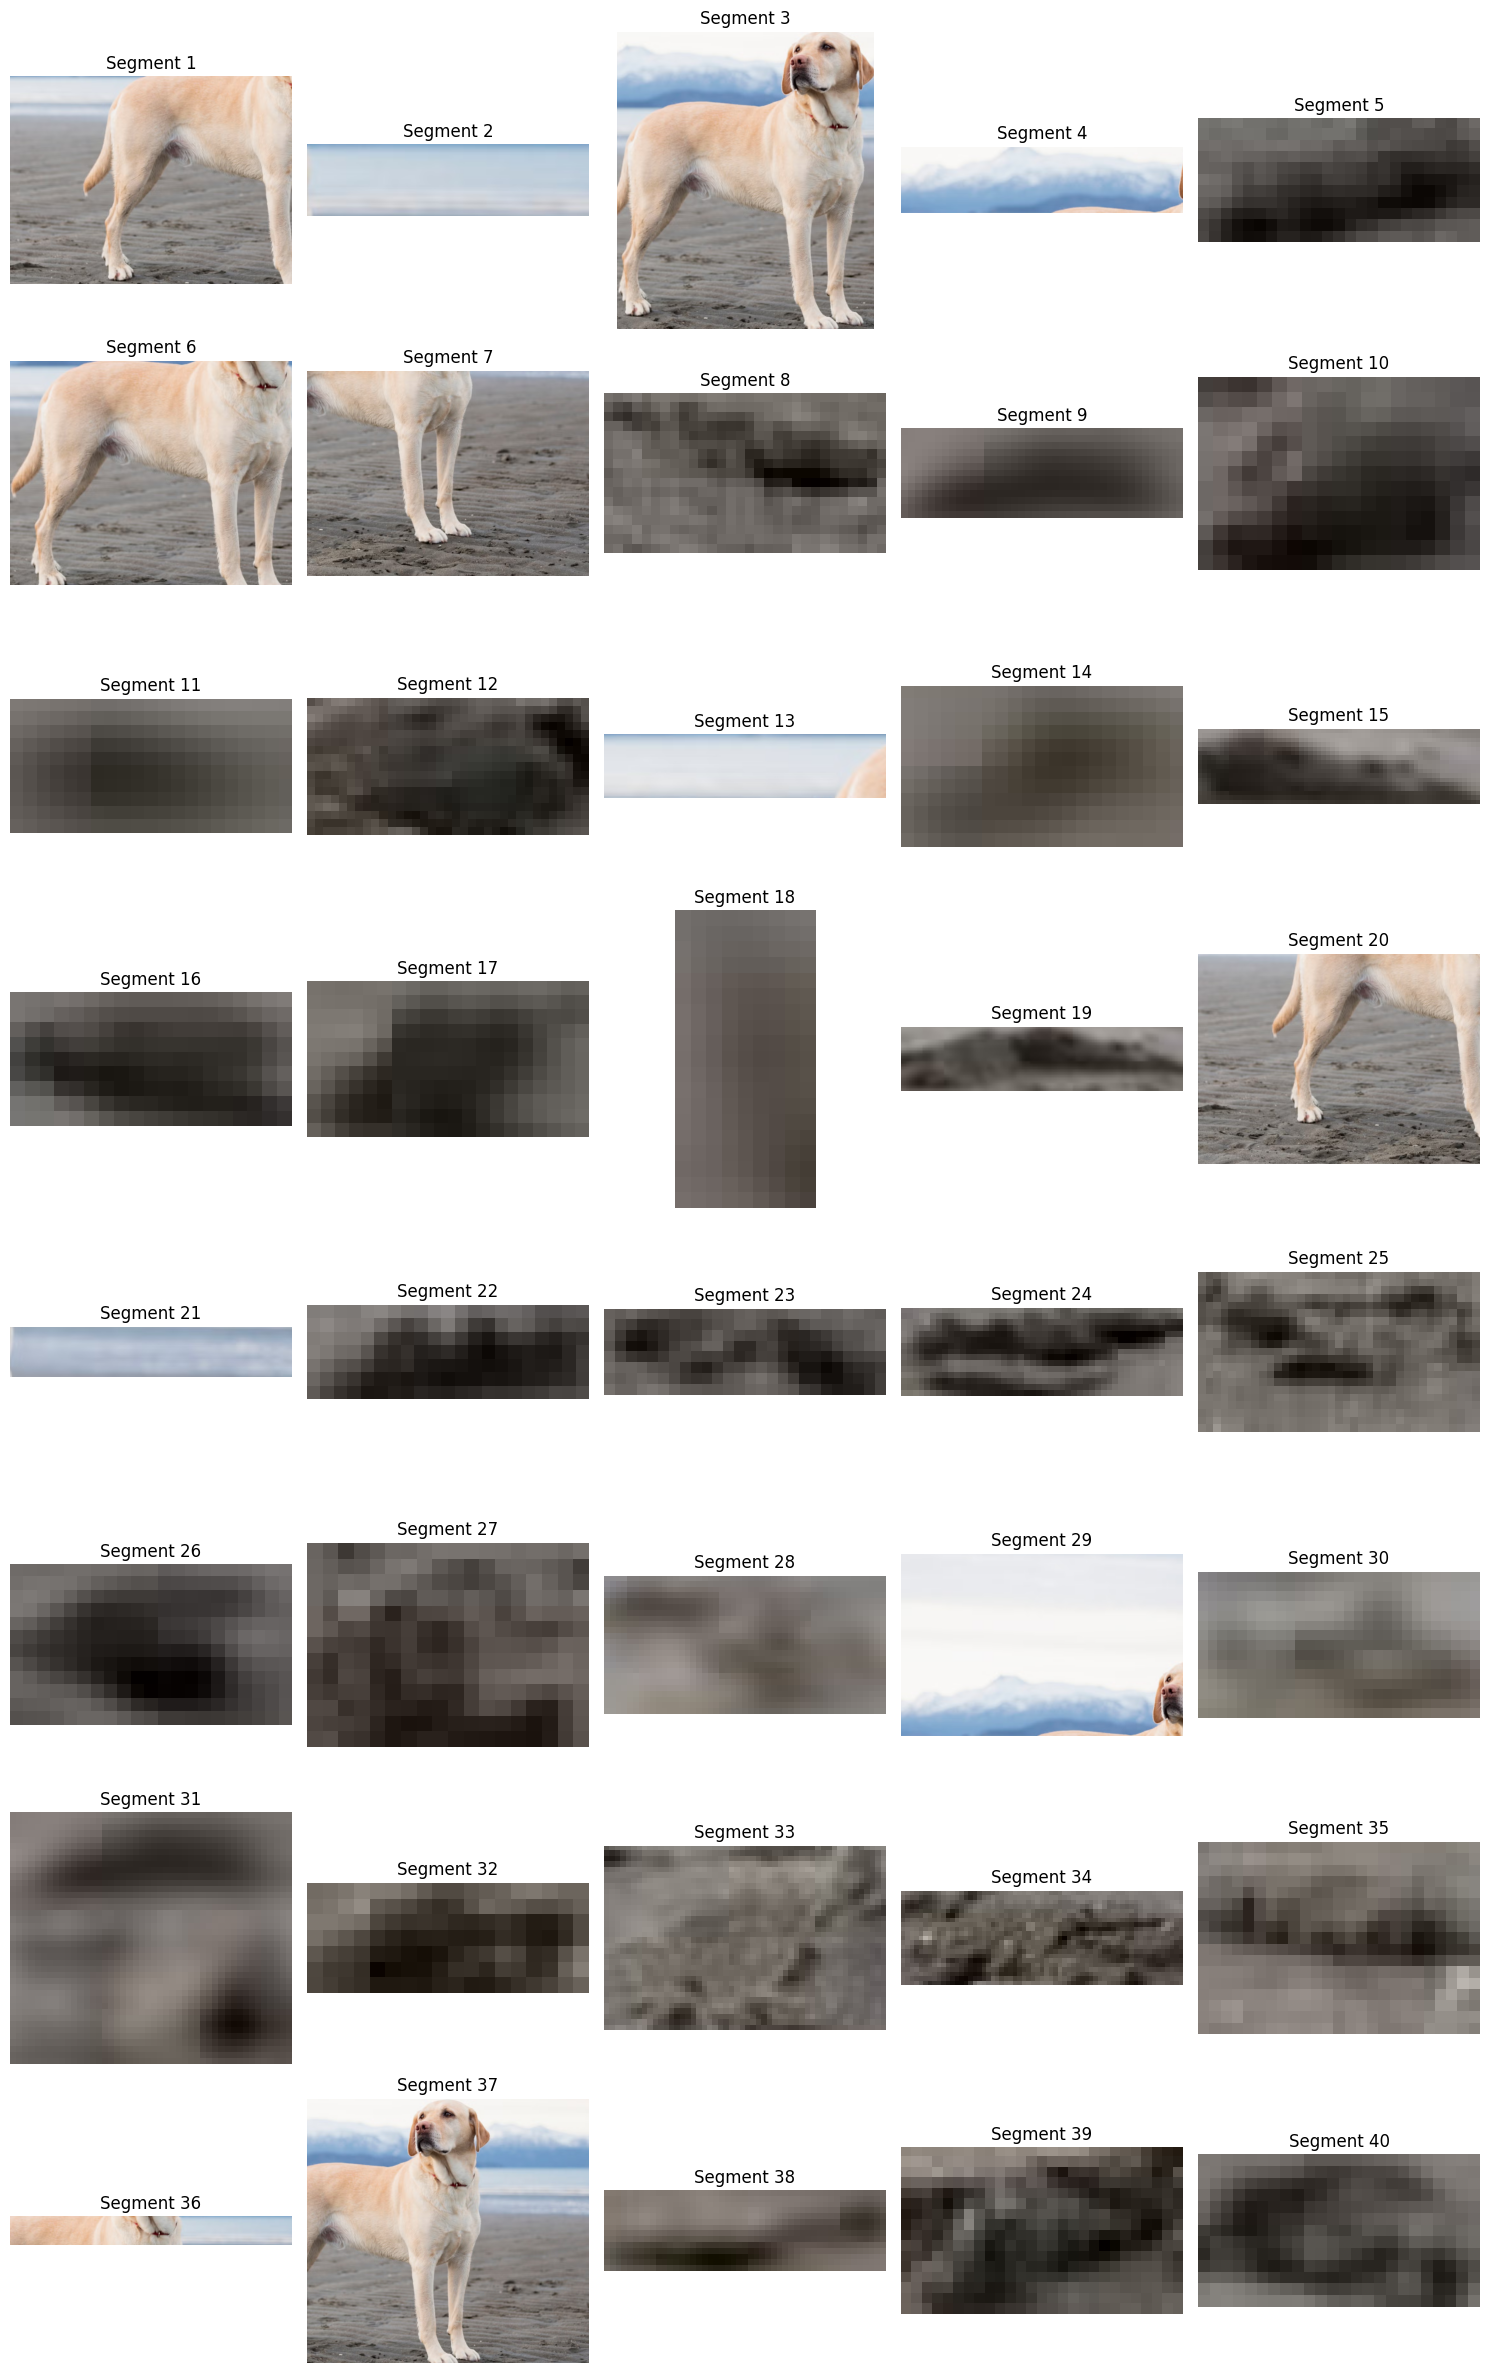

In [6]:
import math

def show_crops(results_obj, original_img):
    if results_obj[0].boxes is not None:
        # Tespit edilen kutuları al (x1, y1, x2, y2)
        boxes = results_obj[0].boxes.xyxy.cpu().numpy()
        num_boxes = len(boxes)

        if num_boxes == 0:
            print("Hiç nesne tespit edilemedi.")
            return

        # Görselleştirme için ızgara yapısını ayarla
        cols = 5
        rows = math.ceil(num_boxes / cols)

        plt.figure(figsize=(15, 3 * rows))

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box)
            # Sınırları kontrol et
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(original_img.shape[1], x2), min(original_img.shape[0], y2)

            # Nesneyi kırp
            crop = original_img[y1:y2, x1:x2]

            plt.subplot(rows, cols, i + 1)
            plt.imshow(crop)
            plt.title(f"Segment {i+1}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Kırpılmış nesneleri göster
show_crops(results, img_orig)

### 5. Adım: Tespit Edilen Toplam Segment Sayısı

Modelin kaç adet nesne/segment bulduğunu öğrenmek için `len()` fonksiyonunu kullanabiliriz.

In [7]:
if results[0].masks is not None:
    toplam_segment = len(results[0].masks)
    print(f"Model bu resimde toplam {toplam_segment} adet segment tespit etti.\n")

    print("Segment Lokasyonları (x1, y1, x2, y2):")
    for i, box in enumerate(results[0].boxes.xyxy):
        coords = box.cpu().numpy()
        print(f"Segment {i+1}: {coords}")
else:
    print("Hiç segment bulunamadı.")

Model bu resimde toplam 40 adet segment tespit etti.

Segment Lokasyonları (x1, y1, x2, y2):
Segment 1: [          0      619.14      886.02      1271.9]
Segment 2: [     1034.2      617.81        1420      715.38]
Segment 3: [     283.84      383.01      1074.9      1301.2]
Segment 4: [          0       429.1      801.78      618.77]
Segment 5: [     1360.1      1374.6      1385.7        1385]
Segment 6: [     227.34      602.36      1037.8      1247.9]
Segment 7: [     511.99      755.47        1420        1416]
Segment 8: [     1260.5      1399.5      1290.2        1416]
Segment 9: [     1124.4      1008.6      1165.5      1021.6]
Segment 10: [     1209.4      1329.5      1228.7      1342.1]
Segment 11: [     1226.7      1045.2      1247.1      1055.7]
Segment 12: [     790.68      1322.4      825.59      1339.8]
Segment 13: [          0      619.35      391.51      707.82]
Segment 14: [     1290.1      1050.1      1311.5      1062.3]
Segment 15: [      41.72      1202.6      105.94


### 6. Adım: Daha İyi Sonuçlar İçin Nokta Belirteci (Point Prompt)

Eğer tüm resim yerine sadece belirli bir nesneyi (örneğin sadece köpeği) seçmek isterseniz, resim üzerinde bir nokta belirleyebilirsiniz. Koordinatlar `[x, y]` formatındadır.


🔄 İşlem başlatılıyor... Cihaz: cpu

image 1/1 /content/gettyimages-586890581.png: 1024x1024 40 objects, 2350.3ms
Speed: 10.5ms preprocess, 2350.3ms inference, 752.4ms postprocess per image at shape (1, 3, 1024, 1024)


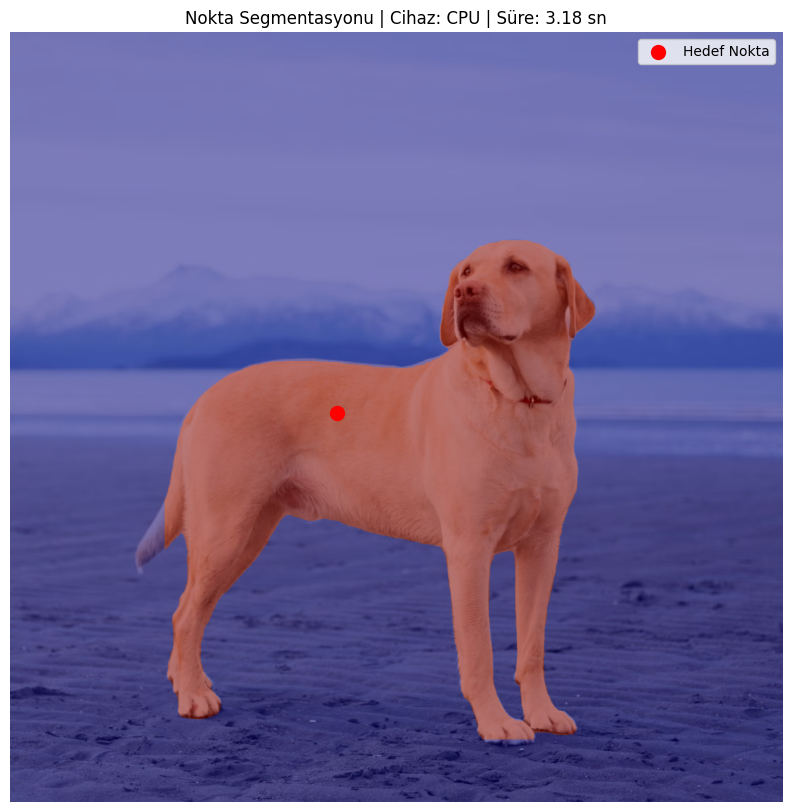

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import time

# --- MANUEL SEÇİM ---
# İşlemci ile devam etmek için 'cpu' seçili
cihaz_secimi = 'cpu'
# --------------------

print(f"🔄 İşlem başlatılıyor... Cihaz: {cihaz_secimi}")

def run_inference(device_name):
    baslangic = time.time()

    try:
        # Modeli seçilen cihazda (CPU) çalıştır
        results = model(img_path, device=device_name, retina_masks=True, imgsz=1024, conf=0.25)
        bitis = time.time()

        res = results[0]
        # Örnek nokta: Köpeği seçmek için
        target_point = (600, 700)

        found_mask = None
        if res.masks is not None:
            masks_data = res.masks.data.cpu().numpy()
            for mask_np in masks_data:
                h, w = mask_np.shape
                y, x = int(target_point[1] * h / 1024), int(target_point[0] * w / 1024)
                x = min(max(0, x), w-1)
                y = min(max(0, y), h-1)
                if mask_np[y, x] > 0:
                    found_mask = mask_np
                    break

        if found_mask is not None:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10, 10))
            plt.imshow(img)
            plt.imshow(found_mask, alpha=0.5, cmap='jet')
            plt.scatter([target_point[0]], [target_point[1]], color='red', s=100, label='Hedef Nokta')
            plt.title(f"Nokta Segmentasyonu | Cihaz: {device_name.upper()} | Süre: {bitis-baslangic:.2f} sn")
            plt.axis('off')
            plt.legend()
            plt.show()
        else:
            print("Bu noktada bir nesne bulunamadı. Koordinatları kontrol edin.")

    except Exception as e:
        print(f"❌ Bir hata oluştu: {e}")

run_inference(cihaz_secimi)

### Adım 6.1: Çoklu Segment Birleştirme (Kapsayıcı Maske)

Bazı durumlarda bir nesne birden fazla parçaya bölünmüş olabilir. Bu hücrede, hedef noktanın temas ettiği tüm maskeleri bulup tek bir büyük maske haline getiriyoruz.

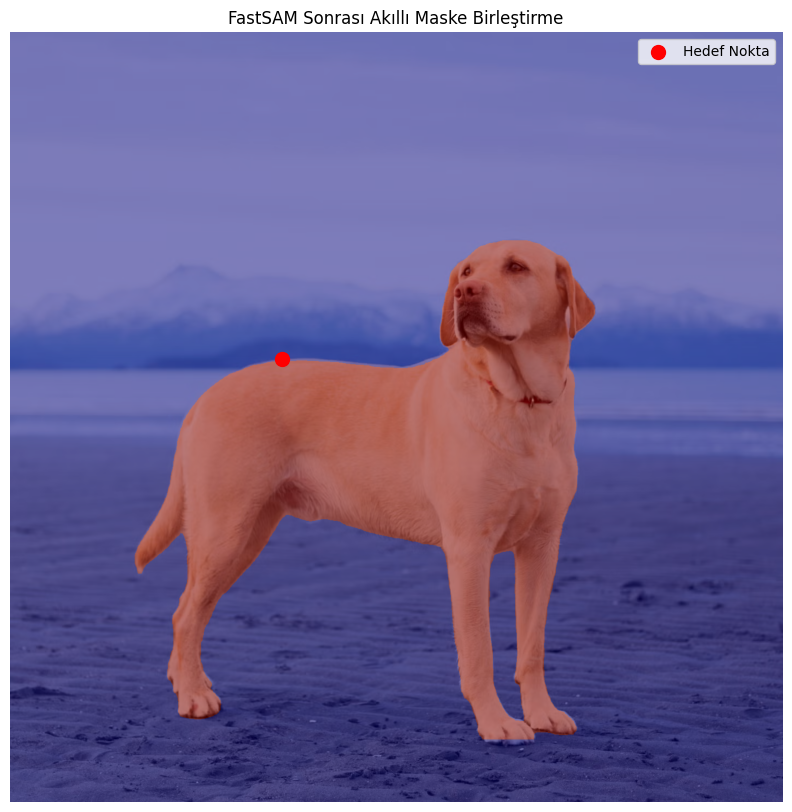

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import FastSAM

def run_merged_inference(target_point):
    # Bağımlılığı kontrol et ve gerekirse modeli/resmi hazırla
    try:
        # Eğer results değişkeni yoksa (restart sonrası), hızlıca FastSAM-s çalıştır
        if 'results' not in globals() or results[0].path != img_path:
            temp_model = FastSAM('FastSAM-s.pt')
            current_results = temp_model(img_path, retina_masks=True, imgsz=1024, conf=0.25, verbose=False)
            res = current_results[0]
        else:
            res = results[0]

        if res.masks is not None:
            masks_data = res.masks.data.cpu().numpy()
            h, w = masks_data[0].shape

            # Noktanın koordinatlarını maske boyutuna uyarla
            py, px = int(target_point[1] * h / 1024), int(target_point[0] * w / 1024)
            px = min(max(0, px), w-1)
            py = min(max(0, py), h-1)

            # Bu noktayı içeren TÜM maskeleri bul ve birleştir
            merged_mask = np.zeros((h, w), dtype=np.uint8)
            found_any = False

            for mask_np in masks_data:
                if mask_np[py, px] > 0:
                    merged_mask = np.logical_or(merged_mask, mask_np)
                    found_any = True

            if found_any:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                plt.figure(figsize=(10, 10))
                plt.imshow(img)
                plt.imshow(merged_mask.astype(float), alpha=0.5, cmap='jet')
                plt.scatter([target_point[0]], [target_point[1]], color='red', s=100, label='Hedef Nokta')
                plt.title("FastSAM Sonrası Akıllı Maske Birleştirme")
                plt.axis('off')
                plt.legend()
                plt.show()
            else:
                print("Belirlenen noktada bir segment bulunamadı.")
    except Exception as e:
        print(f"Hata: {e}. Lütfen önce fastSAM  hücresinde bir resim yüklediğinizden emin olun.")

# Köpeğin olduğu bölgeden bir nokta deneyelim (Koordinatları resminize göre güncelleyebilirsiniz)
run_merged_inference((500, 600))

## Adım 7: SAM 2 (Segment Anything Model 2) - GPU Performansı

Bu bölüm, GPU çalışma zamanına geçiş yapıp kernel restart attıktan sonra **hiçbir hücreye bağımlı kalmadan** çalışacak şekilde tasarlanmıştır.

In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
import time
import os
from google.colab import files

# 1. Gerekli kütüphaneyi kontrol et ve yoksa kur
try:
    from ultralytics import SAM
except ImportError:
    !pip install -q ultralytics
    from ultralytics import SAM

# 2. Donanım Kontrolü
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"[BİLGİ] Kullanılan Cihaz: {device.upper()}")
if device == 'cpu':
    print("⚠️ UYARI: GPU algılanmadı, SAM 2 yavaş çalışabilir.")

# 3. Yeni Resim Yükle
print("\n--- Lütfen İşlenecek Resmi Seçin ---")
uploaded_sam2 = files.upload()
sam2_img_path = list(uploaded_sam2.keys())[0]

# 4. SAM 2 Modelini Yükle ve Tahmin Yürüt
print("\n🚀 SAM 2 Model yükleniyor ve GPU üzerinde çalıştırılıyor...")
sam2_model = SAM('sam2_s.pt')

start_time = time.time()
results = sam2_model.predict(sam2_img_path, device=device, conf=0.25)
end_time = time.time()

# 5. Görselleştirme
res_plot = results[0].plot()
res_rgb = cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(res_rgb)
plt.title(f"SAM 2 Segmentasyon ({device.upper()} | {end_time - start_time:.2f} sn)")
plt.axis('off')
plt.show()

if results[0].masks is not None:
    print(f"✅ Başarılı! Toplam {len(results[0].masks)} nesne segmentlere ayrıldı.")

### Adım 7.1: SAM 2 ile Sadece Nesneyi Ayıklama

Bu hücrede, SAM 2'nin ürettiği maskeler arasından belirli bir noktaya (köpeğin üzerine) denk geleni seçip, nesneyi orijinal renkleriyle tutup arka planı grileştirerek 'foreground' ayıklama işlemi yapıyoruz.

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def isolate_object_sam2(results_obj, original_path, target_point):
    img = cv2.imread(original_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    found_mask = None
    if results_obj[0].masks is not None:
        # Maskeleri al
        masks = results_obj[0].masks.data.cpu().numpy()

        # Hedef noktayı maske boyutuna göre ölçeklendir
        mh, mw = masks[0].shape
        px = int(target_point[0] * mw / w)
        py = int(target_point[1] * mh / h)

        # Noktayı içeren maskeyi bul
        for m in masks:
            if m[py, px] > 0.5:
                found_mask = m
                break

    if found_mask is not None:
        # HATA DÜZELTME: Maskeyi önce float32/uint8 tipine çeviriyoruz (OpenCV bool sevmez)
        full_mask = cv2.resize(found_mask.astype(np.float32), (w, h))

        # Arka planı grileştir, nesneyi bırak
        background = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        background = cv2.cvtColor(background, cv2.COLOR_GRAY2RGB)
        background = (background * 0.3).astype(np.uint8) # Karartma efekti

        # Maske kullanarak birleştir
        foreground = np.where(full_mask[..., None] > 0.5, img, background)

        plt.figure(figsize=(12, 12))
        plt.imshow(foreground)
        plt.title("SAM 2: Ayıklanan Ön Plan (Foreground) Nesnesi")
        plt.axis('off')
        plt.show()
    else:
        print("Belirtilen koordinatta bir nesne bulunamadı.")

# Köpek koordinatıyla (500, 600) ayıklama yapalım
isolate_object_sam2(results, sam2_img_path, (500, 600))

NameError: name 'sam2_img_path' is not defined